In [1]:
import pymc as pm
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import matplotlib.cm as cm
import pandas as pd
import pytensor.tensor as pt
import json

#Make sure it can see the system path

# import sys
# from pathlib import Path

# PROJECT_ROOT = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
# sys.path.insert(0, str(PROJECT_ROOT))

import sys
from pathlib import Path

# Go up one level from notebooks/ to repo root
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from utils import load_data,plot_helpers
from modeling import bayes,viz
from importlib import reload
from modeling import DATA_DIR

In [2]:
for_paper=True
for_talk=False

if for_paper:

    import scienceplots #http://doi.org/10.5281/zenodo.4106649
    plt.style.use(('science','nature'))
elif for_talk:
    plt.style.use("dark-background")
else:
    pass
    #az.style.use("arviz-doc")
    
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

save_figs=False

# Load the data and lookup_table
Both from Norman - get reference?

In [3]:
lookup_table=xr.open_dataarray(DATA_DIR/"carbon_cycle/lookup_table.nc")

carbon_cycle_cmip=load_data.load_carbon_cycle()

In [4]:
if save_figs:
    viz.show_highlevel_tree("paper",save_filename="FIGS/Highleveltree.pdf")
else:
    viz.show_highlevel_tree("jupyter")
#plt.show()

### Which processes are we considering?

In [5]:
lookup_table.process.values

array(['nitrogen', 'permafrost', 'fire', 'veg'], dtype='<U10')

# Explicitly modeling process inclusion/exclusion


## Nitrogen
Some models have nitrogen limitations, others don't.  The ones that do have lower $\beta_L$.  This is expected from physics: you can't take advantage of increased atmospheric CO2 if you're limited by something else.

In [6]:
def plot_comparison(proc_name,vari="betaL"):
    lookup_proc=lookup_table.sel(process=proc_name).values
    
    sns.kdeplot(carbon_cycle_cmip[vari][np.where(lookup_proc)],color=cm.tab10(2),\
                fill=True,label=proc_name)
    sns.kdeplot(carbon_cycle_cmip[vari][np.where(lookup_proc==0)],color=cm.tab10(1),\
                fill=True,label=f"No {proc_name}")
    plt.legend()
    if vari=="betaL":
        plt.xlabel(r"$\beta_{L}$")
    elif vari == "gammaL":
        plt.xlabel(r"$\gamma_{L}$")
    
    

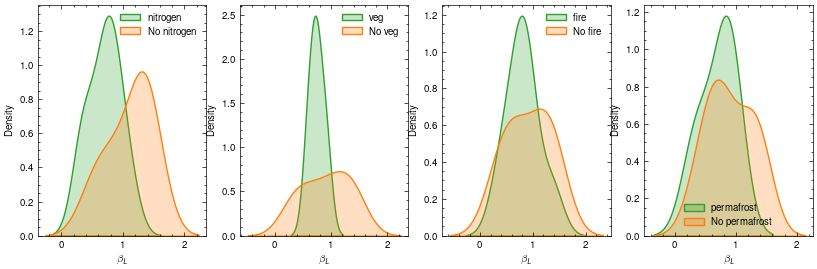

In [7]:
plt.figure(figsize=(10,3))
plt.subplot(141)
plot_comparison("nitrogen",vari="betaL")
plt.subplot(142)
plot_comparison("veg",vari="betaL")
plt.subplot(143)
plot_comparison("fire",vari="betaL")
plt.subplot(144)
plot_comparison("permafrost",vari="betaL")
if save_figs:
    plt.savefig("../FIGS/process_comparisons_beta.pdf")

So let's model this explicitly:
$$ \beta_L^m \sim MN(\eta_N^{L_m}B_L,\Sigma)$$
where $L_m=1$ if ESM m has the process and $L_m=0$  otherwise.  $B_L$ is the unscaled CO2 effect in the absence of nitrogen limitations.

In [8]:
priors_mult={"eta":{"nitrogen":lambda name: pm.Normal(name,0,1)}}
#priors_mult["eta"]["nitrogen"] = lambda name: pm.Normal(name,0,.5)
priors={"sigma_iv": lambda name: .01, "betaL":lambda name: pm.LogNormal(name,0.0,0.5)} | priors_mult



In [9]:
with bayes.build_correlated_bias_model_with_processes(
    carbon_cycle_cmip["betaL"],
    lookup_table,
    additive_processes=None,
    multiplicative_processes=["nitrogen"],
    priors=priors,
    var_name="betaL",
    mu_iv=None,
) as nitrogenmodel:
    nitrogentrace=pm.sample(target_accept=.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betaL_unscaled, sigma_struct, sigma_eta, eta_log_nitrogen, rho, betaL_CMIP_unscaled]


/Users/kmarvel/miniconda3/envs/cmip_bayes/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 44 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


This leads to a posterior much closer to the "with nitrogen" models:

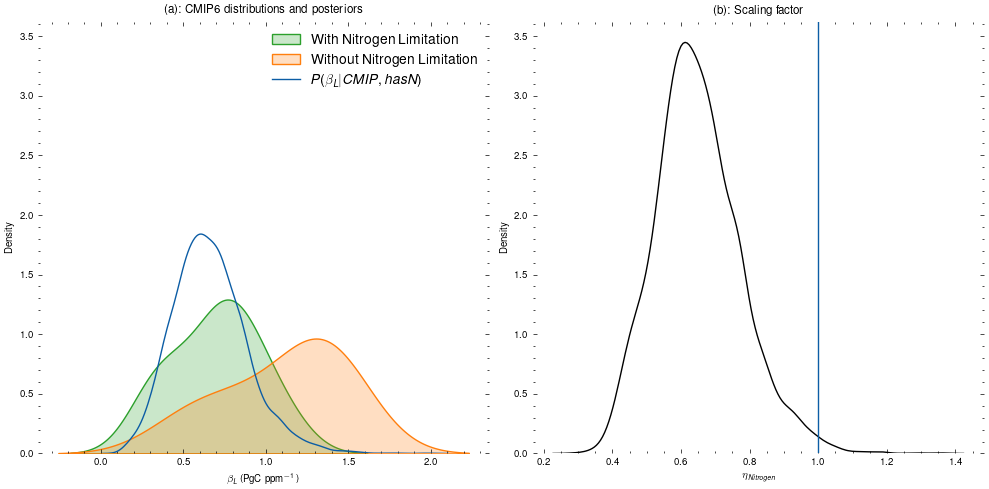

In [44]:
fig=plt.figure(figsize=(10,5))
ax1=plt.subplot(121)
lookup_nitrogen=lookup_table.sel(process="nitrogen").values


sns.kdeplot(carbon_cycle_cmip["betaL"][np.where(lookup_nitrogen)],\
            color=cm.tab10(2),fill=True,label="With Nitrogen Limitation")
sns.kdeplot(carbon_cycle_cmip["betaL"][np.where(lookup_nitrogen==0)],\
            color=cm.tab10(1),fill=True,label="Without Nitrogen Limitation")


plot_helpers.plot_posterior(nitrogentrace,"betaL",label=r"$P(\beta_{L} | CMIP,hasN)$",ax=ax1)
ax1.set_frame_on(False)

plt.xlabel(r"$\beta_{L}$ (PgC ppm$^{-1})$")
plt.legend(fontsize=10)
ax2=plt.subplot(122)
#az.plot_posterior(nitrogentrace.posterior.eta,ref_val=1.0,ax=ax2,c="k",textsize=10)
sns.kdeplot(nitrogentrace.posterior.eta.values.flatten(),color="k")
plt.axvline(1)
ax2.set_xlabel(r"$\eta_{Nitrogen}$")
ax2.set_title("(b): Scaling factor")
ax1.set_ylim(ax2.get_ylim())
ax1.set_title("(a): CMIP6 distributions and posteriors")
plt.tight_layout()
ax2.set_frame_on(False)

if save_figs:
    plt.savefig(PROJECT_ROOT / "FIGS/Nitrogen.pdf")

This is because the model predicts a nonunit scaling factor eta (which it learns from the difference between the two groups).

Now, build a correlated bias model with ALL processes, assuming
$$ \beta_L^m \sim MN(\prod_p\eta_p^{L_m}B_L+\delta_{permafrost},\Sigma)$$

In [11]:
#test
with bayes.build_correlated_bias_model_with_processes(
    carbon_cycle_cmip["betaL"],
    lookup_table,
    additive_processes=None,
    multiplicative_processes=["nitrogen","fire","veg"],
    priors={"sigma_iv": lambda name: .01,  "betaL":lambda name: pm.LogNormal(name,0.0,0.5)},
    var_name="betaL",
    mu_iv=None,
) as allmodel:
    alltrace=pm.sample(target_accept=.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betaL_unscaled, sigma_struct, sigma_eta, eta_log, rho, betaL_CMIP_unscaled]


/Users/kmarvel/miniconda3/envs/cmip_bayes/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 37 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


array([<Axes: title={'center': 'eta\nnitrogen'}>,
       <Axes: title={'center': 'eta\nfire'}>,
       <Axes: title={'center': 'eta\nveg'}>], dtype=object)

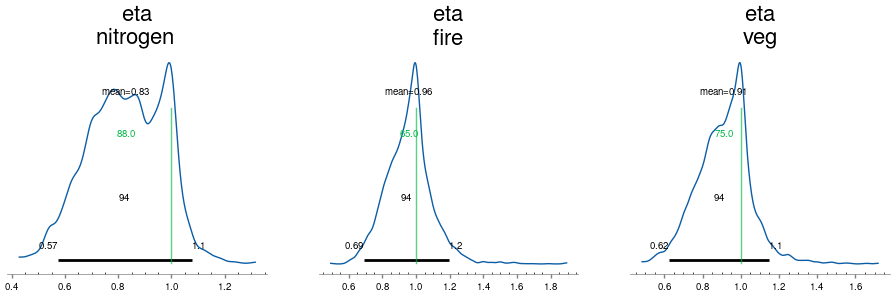

In [12]:
az.plot_posterior(alltrace,var_names=["eta"],ref_val=[1,1,1])

This isn't surprising- the CMIP ESMSs don't really provide enough information to constrain fire, veg, permafrost.

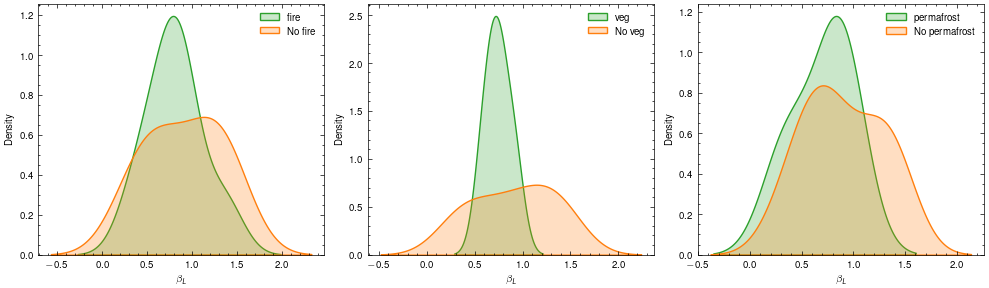

In [13]:
plt.figure(figsize=(10,3))
plt.subplot(131)
plot_comparison("fire")
plt.subplot(132)
plot_comparison("veg")
plt.subplot(133)
plot_comparison("permafrost")
plt.tight_layout()

# We need the priors to do a lot of work for us!
In the case of nitrogen limitations, the models are about 50/50 has process/doesn't.  That, plus the robust physical understanding embedded in the ESMs, means that we can be fairly confident that $\eta_{N}$ is less than 1.  
But for the other processes, we either 1) don't have enough models that included them 2) don't really understand the physical mechanisms by which they affect $\beta_L$.  So the posteriors are unconstrained.  

Note that the "All process" posterior allows for negative values of $\beta_L$ even though my prior on unscaled $\beta_L$ was positive definite.  This is because I used a wide prior on $\delta_{permafrost}$, which allows for the permafrost contribution to be quite negative.  And because permafrost is assumed to be additive, this can drag total $\beta_L$ down to negative values.  If we want to guard against this, we need to specify it in the prior- the CMIP models won't give us the information we need to constrain it.

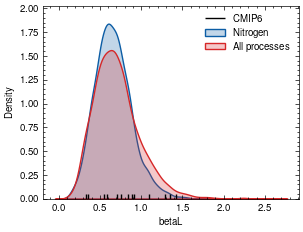

In [14]:
sns.rugplot(carbon_cycle_cmip["betaL"],c="k",label="CMIP6")
plot_helpers.plot_posterior(nitrogentrace,"betaL",label="Nitrogen",fill=True)
plot_helpers.plot_posterior(alltrace,"betaL",label="All processes",color=cm.tab10(3),fill=True)
plt.xlabel("betaL")
plt.legend()


In [15]:
allmodel

     betaL_unscaled ~ LogNormal(0, 0.5)
       sigma_struct ~ HalfNormal(0, 1)
          sigma_eta ~ HalfNormal(0, 0.3)
            eta_log ~ Normal(0, sigma_eta)
                rho ~ Beta(5, 5)
betaL_CMIP_unscaled ~ MultivariateNormal(f(betaL_unscaled, sigma_struct, rho), f(sigma_struct, rho))
                eta ~ Deterministic(f(eta_log))
            eta_eff ~ Deterministic(f(eta_log))
         betaL_CMIP ~ Deterministic(f(betaL_CMIP_unscaled, eta_log))
              betaL ~ Deterministic(f(betaL_unscaled, eta_log))
          betaL_lik ~ Normal(f(betaL_CMIP_unscaled, eta_log), 0.01)

# Use more informative priors


In [16]:
# process priors

#THESE ARE PRIORS ON LOG ETA
mult_priors={"nitrogen": lambda name: pm.Normal(name,-.2,.5),\
            "fire": lambda name: pm.Normal(name,0,.5),\
            "veg": lambda name: pm.Normal(name,.2,.5)}

add_priors={"permafrost":  lambda name: pm.Normal(name,0,.00001)}

tightpriors={"sigma_iv": lambda name: .01,  
        "betaL":lambda name: pm.LogNormal(name,0.0,0.5),
       "eta":mult_priors,
       "delta":add_priors}


with bayes.build_correlated_bias_model_with_processes(
    carbon_cycle_cmip["betaL"],
    lookup_table,
    additive_processes=None,
    multiplicative_processes=["nitrogen","fire","veg"],
    priors=tightpriors,
    var_name="betaL",
    mu_iv=None,
) as tightpriormodel:
    tightpriortrace=pm.sample(target_accept=.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betaL_unscaled, sigma_struct, sigma_eta, eta_log_nitrogen, eta_log_fire, eta_log_veg, rho, betaL_CMIP_unscaled]


/Users/kmarvel/miniconda3/envs/cmip_bayes/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 45 seconds.


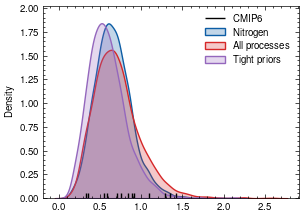

In [17]:
sns.rugplot(carbon_cycle_cmip["betaL"],c="k",label="CMIP6")
plot_helpers.plot_posterior(nitrogentrace,"betaL",label="Nitrogen",fill=True)
plot_helpers.plot_posterior(alltrace,"betaL",label="All processes",color=cm.tab10(3),fill=True)
plot_helpers.plot_posterior(tightpriortrace,"betaL",label="Tight priors",color=cm.tab10(4),fill=True)
plt.legend()

# Adding process-based information
Using the process-based runs, we can constrain $\eta$ and $\delta$.  

### Read in data from Norman
Use the process-based runs provided by Norman Steinart

In [18]:
TCREsource_betagamma = pd.read_csv("../data/carbon_cycle/TCREsource_betagamma.csv")
TCREsource_betagamma = TCREsource_betagamma.set_index("model")
process_pairs = {
    "nitrogen": [
        ("ACCESS-ESM_CN", "ACCESS-ESM_C"),
        ("UKESM1-1_ctrl", "UKESM1-1_nonlim"),
    ],
    "fire": [
        ("UKESM1-1_fire", "UKESM1-1_ctrl"),
    ],
    "vegetation": [
        ("UKESM1-1_ctrl", "UKESM1-1_nodgvm"),
    ],
}

In [45]:
kind="2xCO2"
def compute_process_effects(df, column, process_pairs, mode="ratio"):
    """
    Compute process factors either multiplicatively (ratio)
    or additively (difference).

    mode:
        "ratio" -> numerator / denominator
        "diff"  -> numerator - denominator
    """

    proc = {}

    for proc_name, pairs in process_pairs.items():

        effects = []

        for num, den in pairs:

            num_val = df.loc[num, column]
            den_val = df.loc[den, column]

            if mode == "ratio":
                effects.append(float(num_val / den_val))

            elif mode == "diff":
                effects.append(num_val - den_val)

            else:
                raise ValueError("mode must be 'ratio' or 'diff'")

        proc[proc_name] = effects

    return proc
beta_col = f"beta_L_{kind}"

eta_proc = {
    f"η_{k}": v
    for k, v in compute_process_effects(
        TCREsource_betagamma,
        beta_col,
        process_pairs,
        mode="ratio"
    ).items()
}


Add the process based information to help constrain $\eta_{nitrogen}$

In [20]:
def add_process_information(model,process_name,process_data,process_sigma=.1,process_iteration=None):
      if process_name in model.coords['multiplicative_process']:
            proc_idx=model.coords['multiplicative_process'].index(process_name)
            #Fixed effects 
            if process_iteration is not None:
                label=f"eta_{process_name}_{process_iteration}"
            else:
                label=f"eta_{process_name}"
#             if f"eta_{process_name}" in model.named_vars:
#                 label=f"eta_{process_name}_update"
#             else:
#                 label=f"eta_{process_name}"
            pm.Normal(label,\
                      mu=model["eta"][proc_idx],\
                      sigma=process_sigma,\
                      observed=process_data)
    

In [21]:
nitrogen2= bayes.build_correlated_bias_model_with_processes(
    carbon_cycle_cmip["betaL"],
    lookup_table,
    additive_processes=None,
    multiplicative_processes=["nitrogen"],
    priors=priors,
    var_name="betaL",
    mu_iv=None,
) 
# with nitrogen2:
#     n2trace=pm.sample()

In [22]:
with nitrogen2:
    add_process_information(nitrogen2,"nitrogen",eta_proc["η_nitrogen"],process_iteration="PROC_RUNS")
    nproctrace_proc=pm.sample()
   

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betaL_unscaled, sigma_struct, sigma_eta, eta_log_nitrogen, rho, betaL_CMIP_unscaled]


/Users/kmarvel/miniconda3/envs/cmip_bayes/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


Now do a test: pretend we have lots of evidence that nitrogen limitations don't do anything ($\eta_{nitrogen}=1$)

In [23]:
import copy
nitrogen_clone=copy.copy(nitrogen2)

In [24]:
with nitrogen_clone:
    add_process_information(nitrogen_clone,"nitrogen",np.repeat(1.,1000),process_iteration="ALL_1")

In [25]:
with nitrogen_clone:
    all1trace=pm.sample(target_accept=.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betaL_unscaled, eta_log_nitrogen, rho, sigma_struct, betaL_CMIP_unscaled, sigma_eta]


/Users/kmarvel/miniconda3/envs/cmip_bayes/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


The process-based runs constrain the nitrogen scaling factor relative to the full CMIP6 archive (although note that we've a priori assumed a relatively small spread in $\eta_{nitrogen}$ across models).  The synthetic data tightly constrain the scaling factor to be 1 (not shown, can uncomment out to verify)

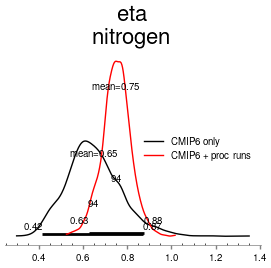

In [26]:
#ax1=plt.subplot(211)
#plot_helpers.plot_posterior(nitrogentrace,"eta",ax=ax1,label=r"$\eta$ (CMIP6 only)")
#plot_helpers.plot_posterior(nproctrace_proc,"eta",ax=ax1,label=r"$\eta$ (CMIP6 + proc runs)")
az.plot_posterior(nitrogentrace.posterior.eta,ax=plt.gca(),c="k",label="CMIP6 only")
az.plot_posterior(nproctrace_proc.posterior.eta,ax=plt.gca(),c="r",label="CMIP6 + proc runs")
#az.plot_posterior(all1trace.posterior.eta,ax=plt.gca(),c="g",label=r"Synthetic $\eta=1$")
plt.legend()

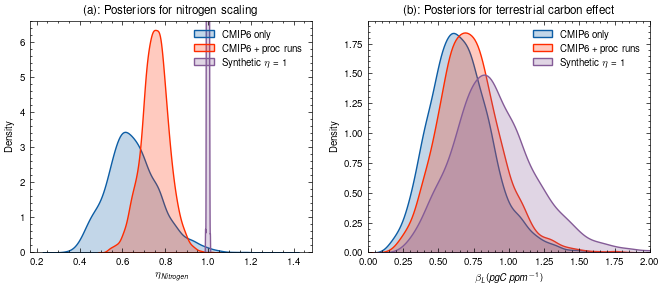

In [47]:

plt.subplot(121)
sns.kdeplot(nitrogentrace.posterior.eta.values.flatten(),label="CMIP6 only",fill=True)
sns.kdeplot(nproctrace_proc.posterior.eta.values.flatten(),label="CMIP6 + proc runs",fill=True,color=colors[3])
sns.kdeplot(all1trace.posterior.eta.values.flatten(),label=r"Synthetic $\eta=1$",fill=True,color=colors[4])
plt.ylim(0,6.6)
plt.xlabel(r"$\eta_{Nitrogen}$")
plt.title("(a): Posteriors for nitrogen scaling")
plt.legend()
ax2=plt.subplot(122)
plot_helpers.plot_posterior(nitrogentrace,"betaL",label="CMIP6 only",fill=True,ax=ax2)
plot_helpers.plot_posterior(nproctrace_proc,"betaL",label="CMIP6 + proc runs",fill=True,ax=ax2,color=colors[3])
plot_helpers.plot_posterior(all1trace,"betaL",label=r"Synthetic $\eta=1$",ax=ax2,fill=True,color=colors[4])
plt.xlabel(r"$\beta_L (pgC \, ppm^{-1})$")
ax2.set_xlim(0,2.0)
plt.legend()
fig=plt.gcf()
fig.get_size_inches()
fig.set_size_inches((8,3))
ax2.set_title("(b): Posteriors for terrestrial carbon effect")

if save_figs:
    plt.savefig(PROJECT_ROOT/"FIGS/process_info.pdf")

Using the process-based evidence doesn't really narrow or shift our posterior, because it doesn't tell us a lot we don't know from CMIP6 already.  But strong (synthetic) evidence that $\eta=1$ would shift the posterior.